# RLBench Unified HDF5 Verification

Visual checks on converted RLBench unified HDF5:
1. All 4 camera slots show real images from distinct viewpoints
2. 7D delta action trajectories are smooth
3. Norm stats are reasonable


In [1]:
import sys
sys.path.insert(0, "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/RAEDiTRobotics")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from data_pipeline.conversion.compute_norm_stats import load_norm_stats

DATA_DIR = "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/data/unified/rlbench"
TASKS = ["close_jar", "open_drawer", "slide_block_to_color_target"]
SLOT_LABELS = ["front", "left_shoulder", "right_shoulder", "wrist"]
ACTION_LABELS = ["Δx", "Δy", "Δz", "Δrx", "Δry", "Δrz", "gripper"]


## 1. Camera Slots — First Frame of demo_0 (all 3 tasks)

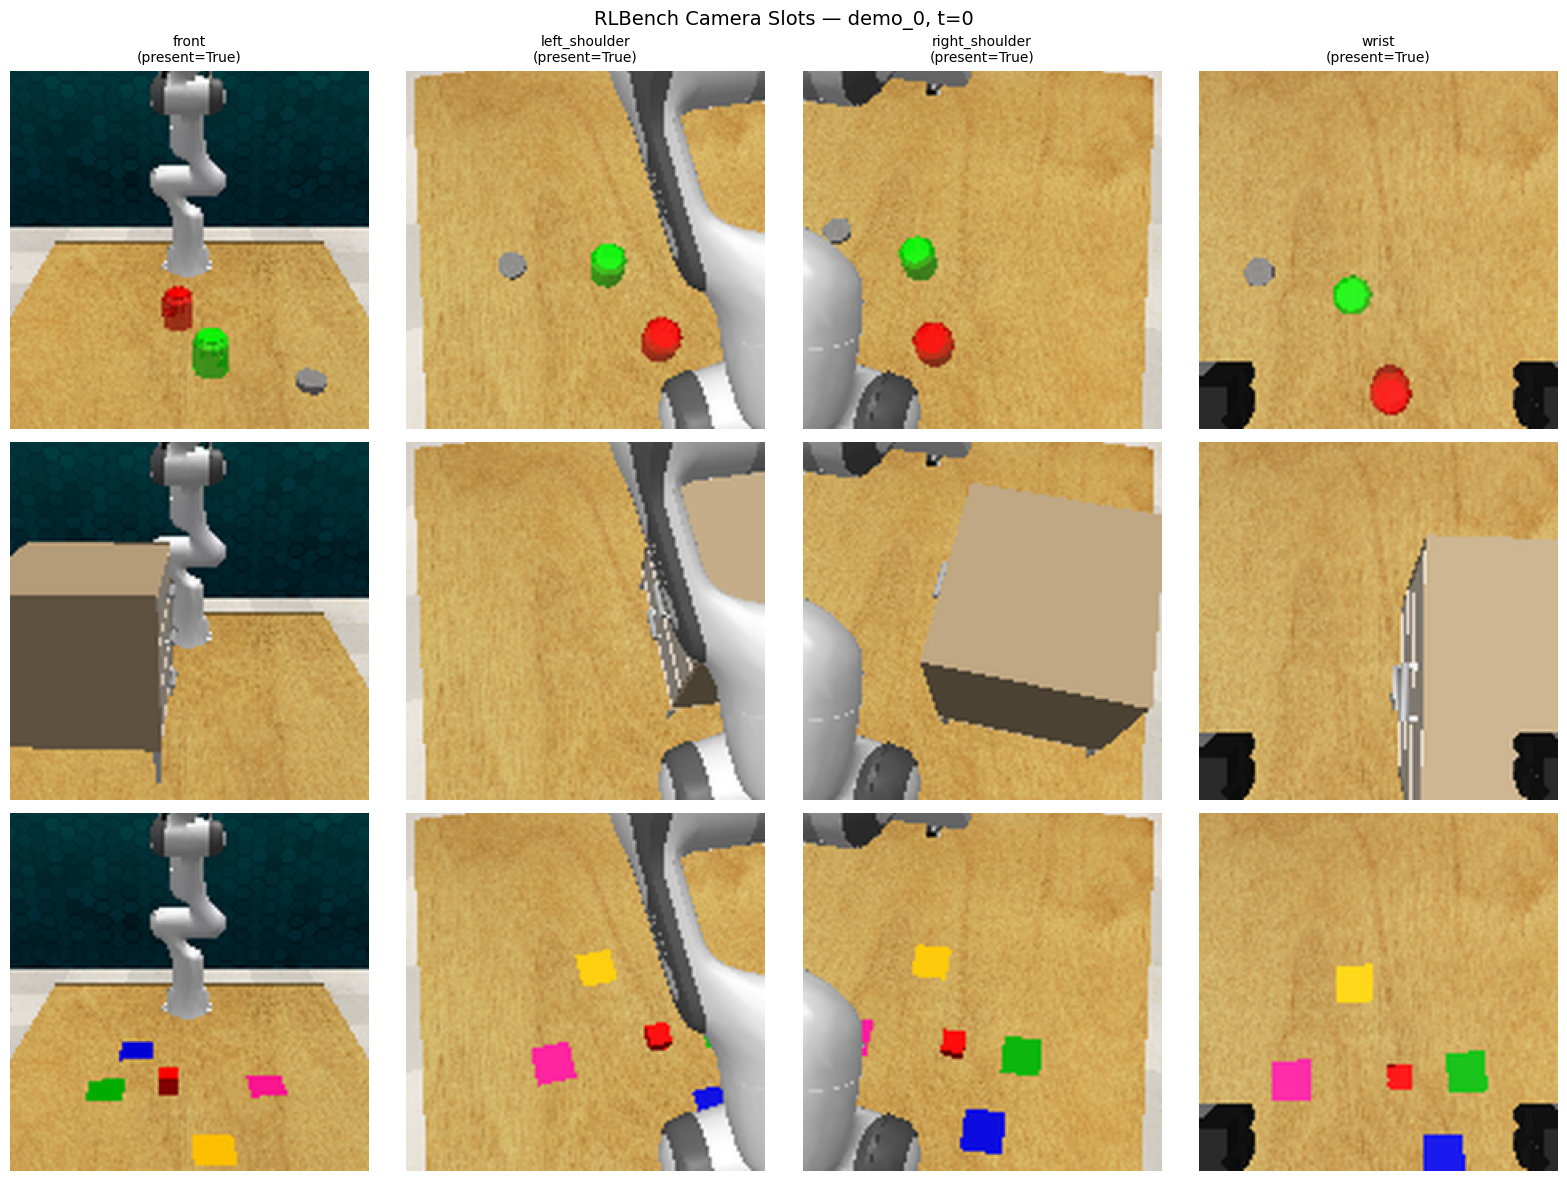

In [2]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row, task in enumerate(TASKS):
    hdf5_path = f"{DATA_DIR}/{task}.hdf5"
    with h5py.File(hdf5_path, "r") as f:
        demo_key = list(f["data"].keys())[0]
        first_frame = f[f"data/{demo_key}/images"][0]  # (4, 224, 224, 3) uint8
        view_present = f[f"data/{demo_key}/view_present"][:]
    for col in range(4):
        ax = axes[row, col]
        ax.imshow(first_frame[col])
        if row == 0:
            ax.set_title(f"{SLOT_LABELS[col]}\n(present={view_present[col]})", fontsize=10)
        ax.axis("off")
    axes[row, 0].set_ylabel(task.replace("_", "\n"), fontsize=11, rotation=0, labelpad=60, va="center")
plt.suptitle("RLBench Camera Slots — demo_0, t=0", fontsize=14)
plt.tight_layout()
plt.show()


## 2. Action Trajectories — demo_0 (all 3 tasks)

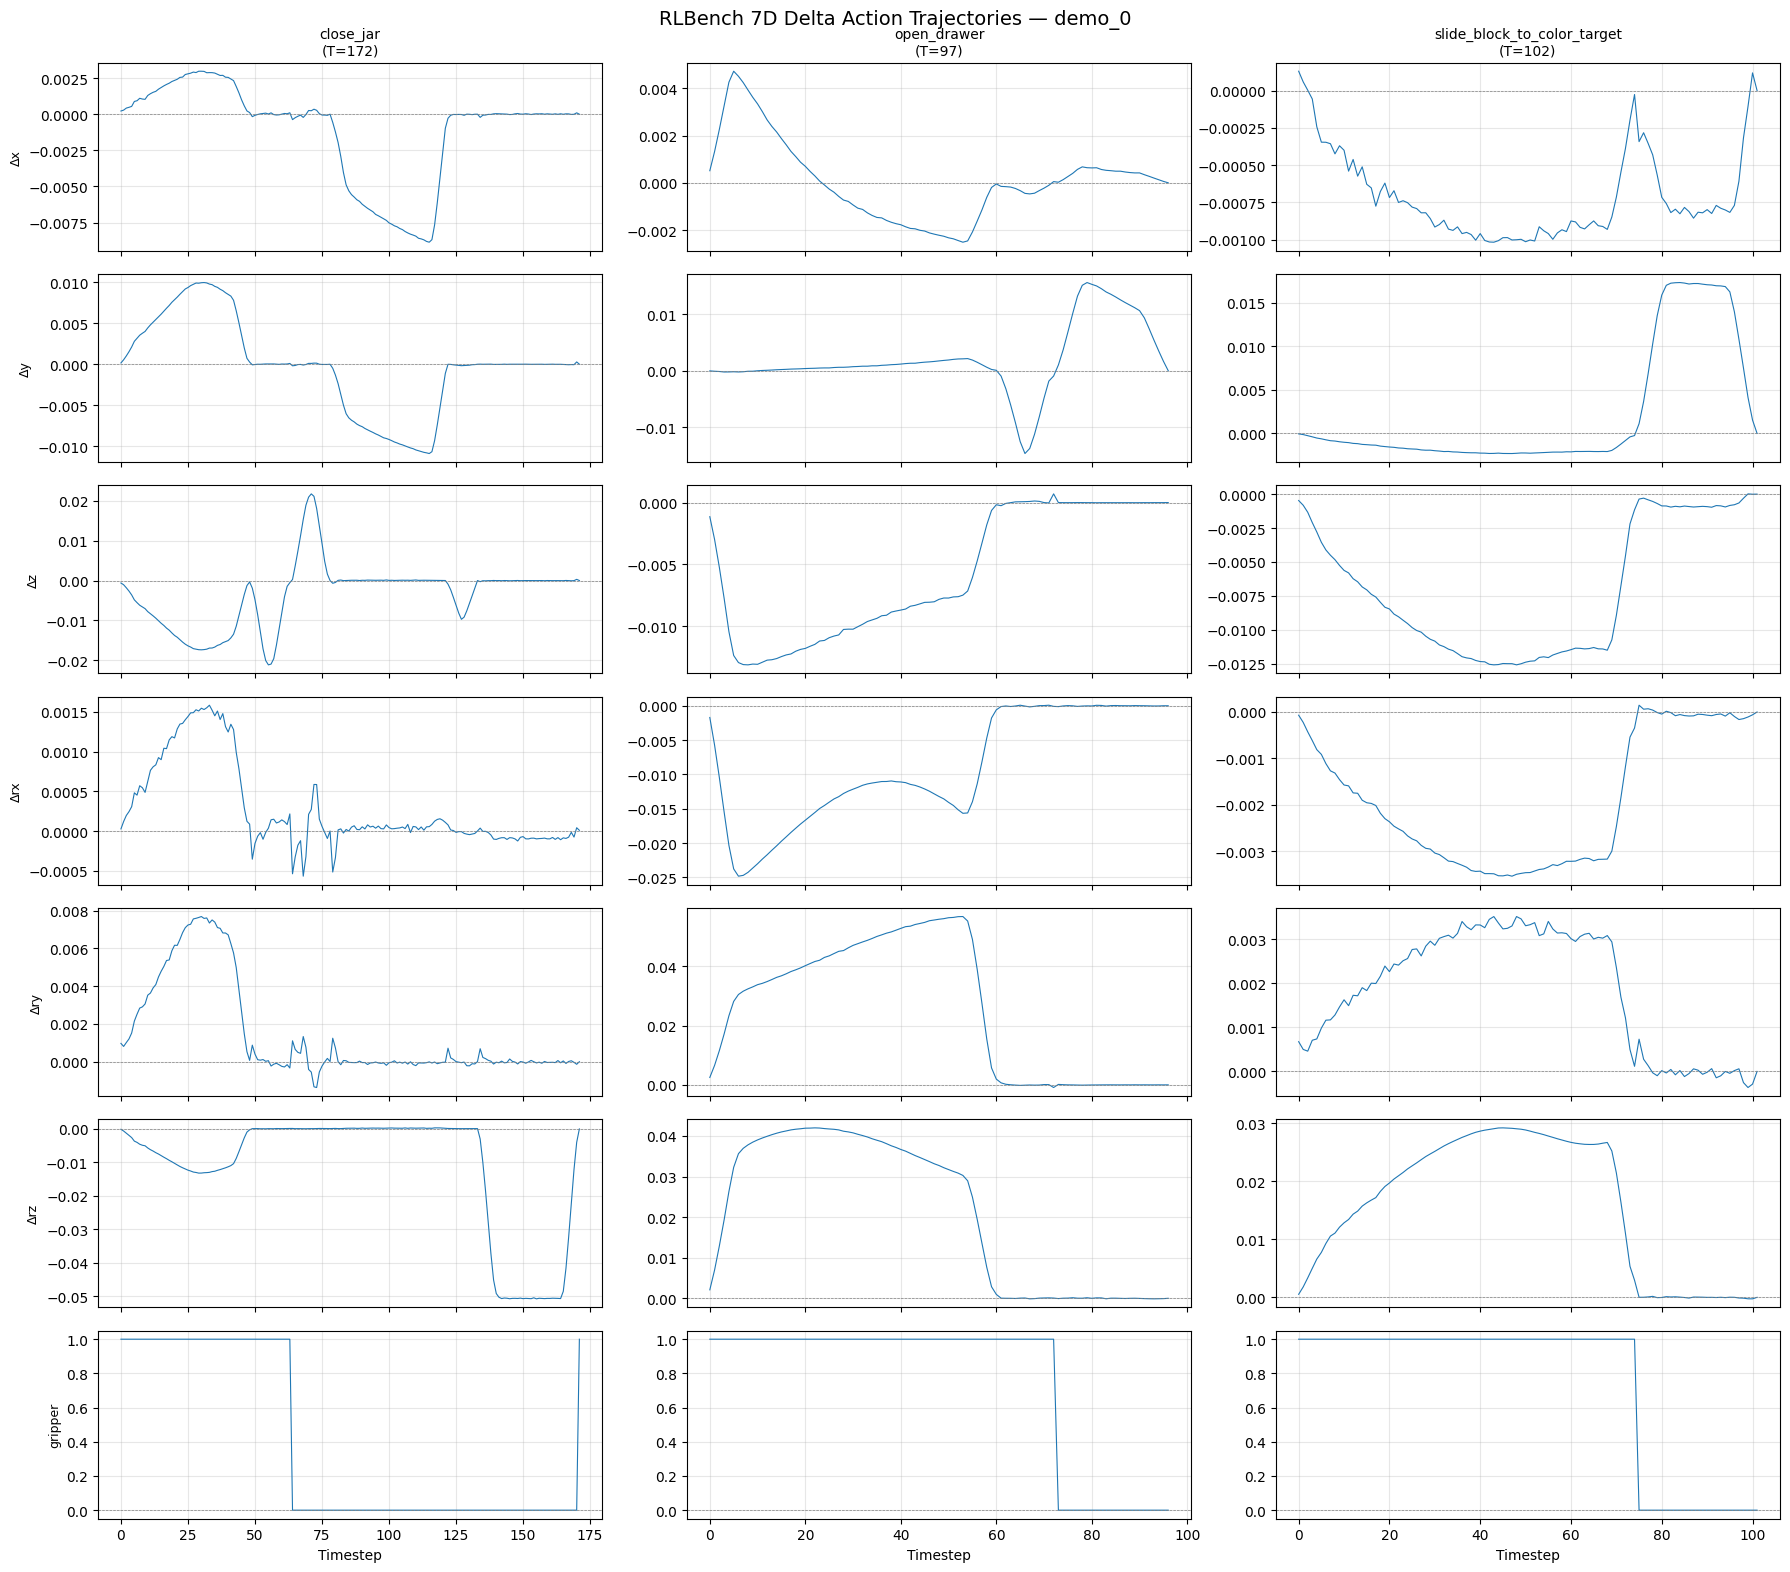

In [3]:
fig, axes = plt.subplots(7, 3, figsize=(18, 16), sharex="col")
for col, task in enumerate(TASKS):
    hdf5_path = f"{DATA_DIR}/{task}.hdf5"
    with h5py.File(hdf5_path, "r") as f:
        demo_key = list(f["data"].keys())[0]
        actions = f[f"data/{demo_key}/actions"][:]
    T = actions.shape[0]
    t = np.arange(T)
    for row in range(7):
        ax = axes[row, col]
        ax.plot(t, actions[:, row], linewidth=0.8)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(ACTION_LABELS[row], fontsize=9)
    axes[0, col].set_title(f"{task}\n(T={T})", fontsize=10)
    axes[6, col].set_xlabel("Timestep")
plt.suptitle("RLBench 7D Delta Action Trajectories — demo_0", fontsize=14)
plt.tight_layout()
plt.show()


## 3. Norm Stats Summary

In [4]:
for task in TASKS:
    hdf5_path = f"{DATA_DIR}/{task}.hdf5"
    stats = load_norm_stats(hdf5_path)
    print(f"--- {task} ---")
    print(f"  Action mean:  {np.round(stats['actions']['mean'], 5)}")
    print(f"  Action std:   {np.round(stats['actions']['std'], 5)}")
    print(f"  Proprio mean: {np.round(stats['proprio']['mean'], 5)}")
    print(f"  Proprio std:  {np.round(stats['proprio']['std'], 5)}")
    print()

--- close_jar ---
  Action mean:  [-7.0000e-05 -4.5000e-04 -3.6600e-03 -3.0000e-05  1.4800e-03 -9.0600e-03
  4.1788e-01]
  Action std:   [0.00301 0.00607 0.00797 0.00131 0.00287 0.02012 0.49321]
  Proprio mean: [ 0.13109  0.27625  0.02359 -1.98965 -0.01661  2.2361   1.05657  0.41788]
  Proprio std:  [0.29412 0.32884 0.25126 0.52739 0.13692 0.42045 0.54515 0.49321]

--- open_drawer ---
  Action mean:  [-4.1000e-04  2.4300e-03 -3.8700e-03 -1.0720e-02  2.0740e-02  2.0390e-02
  7.3446e-01]
  Action std:   [0.00218 0.00578 0.00448 0.0109  0.02035 0.01941 0.44163]
  Proprio mean: [ 0.42142  0.46031  0.04735 -1.50375 -0.76864  1.13601 -0.8192   0.73446]
  Proprio std:  [0.36614 0.26877 0.34249 0.40917 0.43077 0.1837  0.83741 0.44163]

--- slide_block_to_color_target ---
  Action mean:  [-2.3000e-04  1.5000e-04 -4.8300e-03 -7.0000e-04  1.5300e-03  1.0380e-02
  4.9883e-01]
  Action std:   [0.00397 0.00533 0.00542 0.00462 0.00365 0.0241  0.5    ]
  Proprio mean: [-0.06422  0.34299  0.05876 -2.04